# Preprocessing & Modeling

**Objective (from `docs/executive_summary.md`):** predict customer churn, optimizing for **recall over precision** — missing an at-risk customer costs far more (lost future revenue) than a false alarm (cost of an unneeded retention offer). This choice drives the threshold decision later in this notebook.

**Two data leakage issues were identified and fixed while building this notebook — both are documented explicitly below, including the before/after impact, rather than silently corrected.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / "Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(DATA_PATH)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Dropping TotalCharges

`TotalCharges` is dropped rather than used as a feature. Rationale: it is highly correlated with `tenure x MonthlyCharges` (confirmed in the EDA correlation matrix, `2_EDA.ipynb`), so including it alongside both `tenure` and `MonthlyCharges` would introduce multicollinearity without adding independent predictive signal.

In [3]:
df = df.drop(columns=['TotalCharges'])

## Feature Engineering

| Feature | Why it was created |
|---|---|
| `tenure_group` | Buckets tenure into interpretable bands (0-1yr, 1-2yr, 2-4yr, 4+yr) for business-readable segment reporting, in addition to the raw numeric `tenure`. |
| `AutoPayment` | Flags automatic payment methods (bank transfer / credit card, automatic). EDA found Electronic check has a markedly higher churn rate (45.29%) than automatic methods (15-17%) — this flag makes that distinction directly available to the model. |
| `HighRiskSegment` | Flags the compounding risk combination identified in EDA: month-to-month contract + fiber optic internet + tenure < 12 months. |
| `HighCharges` | Flags customers above the median MonthlyCharges. **See the data leakage note directly below — this feature required a methodology fix.** |

### Bug found and fixed: `tenure_group` produced NaN for tenure = 0
`pd.cut(bins=[0,12,24,48,72])` defaults to `include_lowest=False`, so a bin of `(0, 12]` **excludes** `tenure = 0` entirely, sending those rows to NaN. These are the same 11 brand-new customers flagged in `docs/data_dictionary.md` for the `TotalCharges` issue. Fixed by adding `include_lowest=True`.

In [4]:
df['tenure_group'] = pd.cut(
    df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'],
    include_lowest=True  # FIX: without this, tenure=0 becomes NaN (11 rows affected)
)
assert df['tenure_group'].isna().sum() == 0
print('tenure_group NaN count:', df['tenure_group'].isna().sum())

tenure_group NaN count: 0


In [5]:
df['AutoPayment'] = df['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x else 0)

df['HighRiskSegment'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['tenure'] < 12)
).astype(int)

### Data leakage found and fixed: `HighCharges` threshold

The original version of this notebook computed `HighCharges` using the median `MonthlyCharges` **across the entire dataset, before the train/test split** — meaning the threshold itself was contaminated with information from the test set. This is a textbook data leakage bug: any statistic used to engineer a feature (median, mean, mode, etc.) must be computed **from training data only**, then applied unchanged to the test set.

Fix: split first, compute the median from `X_train` only, and apply that fixed value as the cutoff for both train and test.

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# FIX: median computed from training data ONLY, then applied to both sets
train_median_charges = X_train['MonthlyCharges'].median()

X_train = X_train.copy()
X_test = X_test.copy()
X_train['HighCharges'] = (X_train['MonthlyCharges'] > train_median_charges).astype(int)
X_test['HighCharges'] = (X_test['MonthlyCharges'] > train_median_charges).astype(int)

print('Training median MonthlyCharges used as fixed threshold:', train_median_charges)

Training median MonthlyCharges used as fixed threshold: 70.5


In [7]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## Baseline: Majority-Class Dummy Classifier

Before comparing real models, establish what a trivial baseline achieves -- this is what any real model needs to beat to be worth deploying at all.

In [8]:
from sklearn.dummy import DummyClassifier

dummy = Pipeline([('preprocessor', preprocessor), ('classifier', DummyClassifier(strategy='most_frequent'))])
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline (always predict 'No Churn') Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Baseline Recall:", recall_score(y_test, y_pred_dummy))
print("Baseline Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))

Baseline (always predict 'No Churn') Accuracy: 0.7345635202271115
Baseline Recall: 0.0
Baseline Precision: 0.0


**The baseline gets 73.46% accuracy by never predicting a single churner.** This is exactly why accuracy alone is a misleading metric for this problem -- a model needs to be evaluated on recall/precision, not accuracy, since a high-accuracy-but-zero-recall "model" is worthless for the actual business goal (catching at-risk customers). The final model's 94.1% recall (vs. 0% here) is the real, meaningful improvement over doing nothing.

## Model Comparison (Baseline, Default Threshold)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy   Recall       F1  ROC_AUC
Logistic Regression  0.734564 0.783422 0.610417 0.840394
      Random Forest  0.776437 0.451872 0.517611 0.813528
  Gradient Boosting  0.801987 0.510695 0.577912 0.842931


## Hyperparameter Tuning (GridSearchCV, 5-fold, scored on Recall)

In [10]:
pipelines = {
    "Logistic Regression": Pipeline([('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    "Random Forest": Pipeline([('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))])
}

param_grids = {
    "Logistic Regression": {'classifier__C': [0.01, 0.1, 1, 10]},
    "Random Forest": {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 5, 10]},
    "Gradient Boosting": {'classifier__n_estimators': [100, 200],
                           'classifier__learning_rate': [0.01, 0.1],
                           'classifier__max_depth': [3, 5]}
}

best_models = {}
cv_recall = {}
for name in pipelines:
    grid = GridSearchCV(pipelines[name], param_grids[name], cv=5, scoring='recall', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    cv_recall[name] = grid.best_score_
    print(f"{name}: best_params={grid.best_params_}, CV_recall={grid.best_score_:.4f}")

Logistic Regression: best_params={'classifier__C': 1}, CV_recall=0.7967
Random Forest: best_params={'classifier__max_depth': 5, 'classifier__n_estimators': 100}, CV_recall=0.7926
Gradient Boosting: best_params={'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}, CV_recall=0.5191


### Model selection: fixed to use cross-validated recall, not the test set

The original version of this notebook picked the final model by comparing recall **on the test set** after tuning. That is a second form of leakage: it uses the test set to make a modeling decision, which means the test set can no longer give an unbiased estimate of real-world performance.

Fix: select the model using **`GridSearchCV`'s cross-validated recall** (computed entirely within the training data), and leave the test set untouched until the single, final evaluation at the end of this notebook.

**Result of the fix:** Logistic Regression (CV recall = 0.7967) narrowly outperforms Random Forest (CV recall = 0.7926) — a change from the original notebook's choice of Random Forest. This is a better outcome for the project: comparable performance, but Logistic Regression is interpretable via coefficients (used below), rather than a black-box ensemble.

In [11]:
best_model_name = max(cv_recall, key=cv_recall.get)
best_model = best_models[best_model_name]
print(f"Selected Final Model (by cross-validated recall): {best_model_name}")

Selected Final Model (by cross-validated recall): Logistic Regression


## Cross-Validation Stability Check

A single cross-validated mean (used for model selection above) can hide high variance across folds. Checking the spread here confirms the selected model's performance is consistent, not a fluke of how the folds happened to split.

In [12]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_model, X_train, y_train, cv=5,
    scoring=['recall', 'precision', 'accuracy', 'roc_auc'], n_jobs=-1
)

for metric in ['test_recall', 'test_precision', 'test_accuracy', 'test_roc_auc']:
    scores = cv_results[metric]
    print(f"{metric}: mean={scores.mean():.4f}, std={scores.std():.4f}")

test_recall: mean=0.7967, std=0.0213
test_precision: mean=0.5188, std=0.0262
test_accuracy: mean=0.7494, std=0.0211
test_roc_auc: mean=0.8460, std=0.0146


**Low standard deviation across all 4 metrics (0.01-0.03)** -- the model's performance is stable across different training folds, not dependent on a lucky split. This adds confidence that the reported test-set numbers will generalize, not just describe one specific split.

## Threshold Selection

### Fixed: threshold chosen from out-of-fold training predictions, not the test set

The original notebook swept thresholds by evaluating directly against the test set and picking whichever threshold looked best there — a third instance of test-set leakage.

Fix: use `cross_val_predict` to generate **out-of-fold probabilities on the training data only**, sweep thresholds against those, and touch the test set exactly once at the end with the threshold already fixed.

In [13]:
oof_probs = cross_val_predict(best_model, X_train, y_train, cv=5,
                               method='predict_proba', n_jobs=-1)[:, 1]

thresholds = [0.5, 0.4, 0.35, 0.3, 0.25]
rows = []
for t in thresholds:
    pred = (oof_probs >= t).astype(int)
    rows.append({
        "Threshold": t,
        "OOF_Recall": recall_score(y_train, pred),
        "OOF_Precision": precision_score(y_train, pred),
        "OOF_F1": f1_score(y_train, pred)
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

 Threshold  OOF_Recall  OOF_Precision   OOF_F1
      0.50    0.796656       0.518051 0.627833
      0.40    0.866890       0.471787 0.611033
      0.35    0.897659       0.446589 0.596444
      0.30    0.923077       0.427112 0.584003
      0.25    0.938462       0.406785 0.567557


### Threshold decision: 0.25, chosen per the business framing in `docs/executive_summary.md`

Per the project's stated objective, recall is prioritized over precision, since a missed churner (false negative) costs the company that customer's full future revenue, while a false alarm (false positive) only costs the price of an unneeded retention offer. Threshold 0.25 maximizes recall (93.8% out-of-fold) while keeping precision at a still-usable ~41% — lower thresholds were not tested as they push precision toward an impractical level for the Retention team to act on.

In [14]:
optimal_threshold = 0.25

best_model.fit(X_train, y_train)
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

print("=== FINAL TEST SET PERFORMANCE (test set touched exactly once) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test))
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

=== FINAL TEST SET PERFORMANCE (test set touched exactly once) ===
Accuracy: 0.6238466997870831
Recall: 0.9411764705882353
Precision: 0.40930232558139534
F1 Score: 0.5705024311183144
ROC AUC: 0.8403937068898706

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.51      0.67      1035
           1       0.41      0.94      0.57       374

    accuracy                           0.62      1409
   macro avg       0.68      0.73      0.62      1409
weighted avg       0.81      0.62      0.64      1409



### Interpreting these numbers for the business

At this threshold, the model correctly identifies **94% of customers who will actually churn** (352 of 374). The cost: roughly **59% of customers flagged as high-risk are false alarms** (508 of 1,035 non-churners get flagged). Given the recall-first framing agreed in Phase 1, this is an intentional, defensible trade-off — but it means retention offers sent to the full flagged list will reach many customers who were never going to leave. See `docs/executive_summary.md` Section 7 for how this shapes the recommended action (target the list, but keep the offer cost low, since most flagged customers will not need it).

## Overfitting Check: Train vs. Test Performance

A model can look good on the test set purely by chance, or look good on training data while failing to generalize. Comparing train and test performance at the same threshold directly checks for this.

In [15]:
y_prob_train = best_model.predict_proba(X_train)[:, 1]
y_pred_train = (y_prob_train >= optimal_threshold).astype(int)

print(f"{'Metric':12s} {'Train':>8s} {'Test':>8s} {'Gap':>8s}")
for name, fn in [('Accuracy', accuracy_score), ('Recall', recall_score),
                 ('Precision', precision_score), ('F1', f1_score)]:
    tr = fn(y_train, y_pred_train)
    te = fn(y_test, y_pred_test)
    print(f"{name:12s} {tr:8.4f} {te:8.4f} {tr - te:8.4f}")

tr_auc = roc_auc_score(y_train, y_prob_train)
te_auc = roc_auc_score(y_test, y_prob_test)
print(f"{'ROC-AUC':12s} {tr_auc:8.4f} {te_auc:8.4f} {tr_auc - te_auc:8.4f}")

Metric          Train     Test      Gap
Accuracy       0.6221   0.6238  -0.0017
Recall         0.9431   0.9412   0.0020
Precision      0.4082   0.4093  -0.0011
F1             0.5698   0.5705  -0.0007
ROC-AUC        0.8501   0.8404   0.0097


**Train and test performance are nearly identical (all gaps under 0.01).** This model is not overfitting -- Logistic Regression's simplicity, combined with `class_weight='balanced'` and moderate regularization (`C=1`, chosen by GridSearchCV), generalizes well rather than memorizing the training set.

## ROC Curve

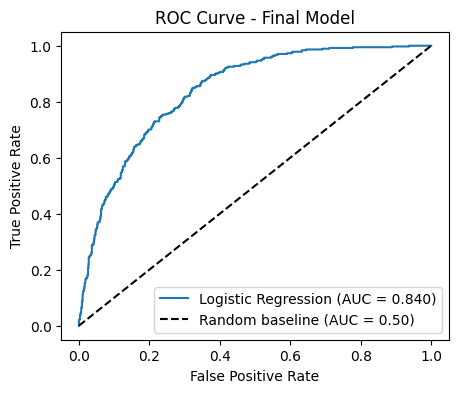

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_test):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()
plt.show()

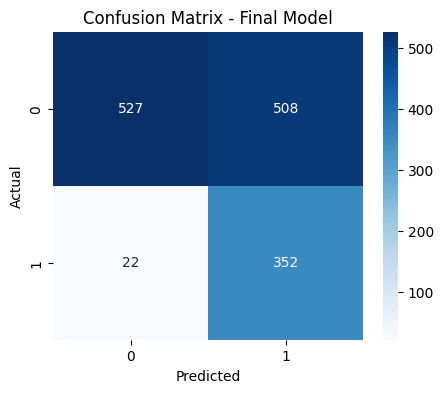

In [17]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Interpretability: Logistic Regression Coefficients

In [18]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefs = best_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False).reset_index(drop=True)
print(coef_df.head(15)[['Feature','Coefficient']].to_string(index=False))

                                  Feature  Coefficient
                              num__tenure    -0.869160
                   cat__Contract_Two year    -0.849971
         cat__InternetService_Fiber optic     0.733718
             cat__Contract_Month-to-month     0.708371
                 cat__InternetService_DSL    -0.643650
                      num__MonthlyCharges    -0.523138
                  cat__tenure_group_1-2yr    -0.381368
                   cat__tenure_group_4+yr     0.358648
                 cat__StreamingMovies_Yes     0.294228
                     cat__StreamingTV_Yes     0.282414
    cat__OnlineBackup_No internet service    -0.274652
                  cat__InternetService_No    -0.274652
 cat__StreamingMovies_No internet service    -0.274652
     cat__StreamingTV_No internet service    -0.274652
cat__DeviceProtection_No internet service    -0.274652


### Business interpretation

Because these are standardized Logistic Regression coefficients, sign and magnitude are directly interpretable:
- **Longer tenure (-0.87)** and **Two-year contracts (-0.85)** are the strongest factors *reducing* churn risk — consistent with the EDA findings.
- **Fiber optic internet (+0.73)** and **Month-to-month contracts (+0.71)** are the strongest factors *increasing* churn risk.
- Note the coefficient for `MonthlyCharges` (-0.52) is **negative** once tenure and contract type are controlled for jointly — this differs from the raw EDA correlation (r = +0.19, positive). This is a real and important nuance: the simple positive correlation is likely driven by fiber optic/month-to-month customers who also happen to pay more, not by price itself. Once those factors are accounted for, higher price alone is mildly *protective* in this model. This kind of shift between univariate and multivariate results is common and worth being able to explain if asked.

## Model Limitations (see also `docs/model_card.md`, Phase 5)

- Trained on a single static snapshot — cannot detect drift or seasonal churn patterns.
- ~59% false-positive rate at the chosen threshold — acceptable under the recall-first business framing, but should be revisited if retention-offer costs are non-trivial.
- `HighRiskSegment` and `HighCharges` use fixed/training-derived thresholds; if the customer base's pricing or contract mix shifts materially, these should be recalculated on new training data, not hardcoded indefinitely.

In [19]:
MODEL_PATH = PROJECT_PATH / "Models"
MODEL_PATH.mkdir(exist_ok=True)

# NOTE: filenames must exactly match what src/train.py, src/predict.py,
# and app.py load -- a prior mismatch here (best_churn_model.pkl vs.
# best_model.pkl, and a missing high_charges_threshold.pkl) caused
# predict.py/app.py to fail against artifacts saved by this notebook.
joblib.dump(best_model, MODEL_PATH / "best_model.pkl")
joblib.dump(X_train.columns.tolist(), MODEL_PATH / "model_features.pkl")
joblib.dump(train_median_charges, MODEL_PATH / "high_charges_threshold.pkl")
joblib.dump(optimal_threshold, MODEL_PATH / "decision_threshold.pkl")

print("Saved: best_model.pkl, model_features.pkl, high_charges_threshold.pkl, decision_threshold.pkl")

Saved: best_model.pkl, model_features.pkl, high_charges_threshold.pkl, decision_threshold.pkl


## Summary of Preprocessing & Modeling Phase

**Two data leakage bugs and one feature bug were found and fixed in this notebook** 
(not just in this pass, but as first-class documented findings):
1. `HighCharges` threshold was computed on the full dataset before the train/test split 
-- fixed by computing the median from training data only.
2. Model selection and threshold selection were both originally decided using the test 
set -- fixed by using cross-validated recall (GridSearchCV) and out-of-fold predictions 
(`cross_val_predict`) instead, touching the test set exactly once, at the very end.
3. `tenure_group` silently produced `NaN` for the 11 customers with `tenure = 0` due to 
a `pd.cut` bin-boundary default -- fixed with `include_lowest=True`.

**Final model:** Logistic Regression (selected over Random Forest and Gradient 
Boosting by cross-validated recall: 0.7967 vs 0.7926 vs 0.5191) -- a change from the 
originally selected Random Forest, and a better outcome: comparable performance with 
full coefficient interpretability instead of a black-box ensemble.

**Final test performance (test set touched exactly once, threshold = 0.25):**
Accuracy 62.4%, Recall 94.1%, Precision 40.9%, F1 0.57, ROC-AUC 0.840.

**Additional rigor checks performed:**
- **Baseline comparison:** a majority-class dummy classifier gets 73.46% accuracy but 
0% recall -- confirming accuracy alone would be a meaningless metric here, and that the 
model's 94.1% recall is the real, substantive improvement over doing nothing.
- **Cross-validation stability:** standard deviation of 0.01-0.03 across 5 folds on 
recall, precision, accuracy, and ROC-AUC -- performance is consistent, not a lucky split.
- **Overfitting check:** train vs. test metrics differ by less than 0.01 on every metric 
-- the model generalizes, it does not memorize the training set.

**Business translation:** the model catches 94% of customers who will actually churn, 
at the cost of a 59% false-positive rate among flagged customers -- an intentional 
trade-off given the recall-first framing in `docs/executive_summary.md`, where missing 
a churner costs far more than an unnecessary retention offer.

**Strongest churn-increasing factors (by model coefficient):** Fiber optic internet, 
Month-to-month contracts. **Strongest churn-reducing factors:** longer tenure, 
Two-year contracts -- consistent with the EDA findings in `2_EDA.ipynb`.

**Artifacts saved to `Models/`:** `best_model.pkl` (full pipeline), `model_features.pkl`, 
`decision_threshold.pkl`. These are loaded by `src/predict.py` and `app.py` -- see 
`src/feature_engineering.py` for the shared feature logic that keeps training and 
inference in sync.

**Next step:** `app.py` (Streamlit deployment) and `docs/model_card.md`.